# CLIP (Contrastive Language-Image Pre-training) 사용 예제

OpenAI의 CLIP은 이미지와 텍스트를 같은 임베딩 공간에 매핑하는 비전-언어 모델입니다.

논문 : https://arxiv.org/abs/2103.00020 

요약 설명 : https://kookie12.tistory.com/2

https://taeyuplab.tistory.com/16

이 노트북에서 다루는 내용:
1. CLIP 모델 로드
2. 이미지-텍스트 유사도 계산
3. Zero-shot 이미지 분류
4. 여러 이미지 중 텍스트와 가장 잘 맞는 이미지 찾기
5. **배치 임베딩 인덱스 (이미지 검색 엔진)**
6. **Prompt Ensemble — 다중 프롬프트 앙상블 분류**
7. **MS COCO Zero-shot 정확도 평가 + 혼동 행렬**
8. **이미지-이미지 유사도 검색**



## 1. 환경 설정

터미널에서 의존성을 설치합니다.

```bash
pip install -r requirements.txt
```

```
torch>=2.0.0
torchvision>=0.15.0
transformers>=4.40.0
pillow>=10.0.0
matplotlib>=3.8.0
requests>=2.31.0
jupyter>=1.0.0
ipykernel>=6.29.0
```

In [1]:
# %pip install ipywidgets

In [1]:
import torch
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from transformers import CLIPProcessor, CLIPModel


def setup_korean_font():
    """matplotlib 한글 폰트 설정 (Windows/Mac/Linux)"""
    for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break
    else:
        print("한글 폰트를 찾지 못했습니다. 제목 한글이 □로 표시될 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False


setup_korean_font()

# GPU 사용 가능 시 cuda, 아니면 cpu
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


## 2. CLIP 모델 로드

`openai/clip-vit-base-patch32`는 가볍고 빠른 기본 모델입니다. 더 높은 정확도가 필요하면 `openai/clip-vit-large-patch14`를 사용할 수 있습니다.

In [2]:
MODEL_NAME = "openai/clip-vit-base-patch32"

# Hugging Face Hub에서 CLIP 모델·전처리기 로드 (최초 실행 시 캐시에 다운로드)
model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model.eval()  # 추론 모드: dropout 등 비활성화

print(f"모델 로드 완료: {MODEL_NAME}")


def to_feature_tensor(output):
    """Transformers 5.x: get_*_features가 tensor 대신 output 객체를 반환할 수 있음"""
    if isinstance(output, torch.Tensor):
        return output
    return output.pooler_output  # L2 정규화 전 투영된 임베딩 벡터

# 모델 다운로드 경로 --> C:\Users\storm\.cache\huggingface\hub\models--openai--clip-vit-base-patch32\
# 약 1.2GB 공간 필요, 약 1분 소요

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

모델 로드 완료: openai/clip-vit-base-patch32


## 3. 샘플 이미지 준비

[MS COCO](https://cocodataset.org/) val2017에서 **예제에 사용할 이미지만** URL로 불러옵니다.
전체 데이터셋(~1GB)을 다운로드하지 않고, COCO 공식 CDN에서 필요한 장수만 가져옵니다.

- 이미지 URL: `http://images.cocodataset.org/val2017/{file_name}`
- CIFAR-10(32×32)보다 **고해상도 실사**라 CLIP zero-shot·검색 데모에 적합
- 카테고리별 5장씩 URL 등록 → 갤러리·정확도 평가에 재사용

로컬 이미지를 쓰려면 `Image.open("경로/이미지.jpg")`로 바꾸면 됩니다.

URL: http://images.cocodataset.org/val2017/000000543581.jpg
category=dog, size=(640, 427)


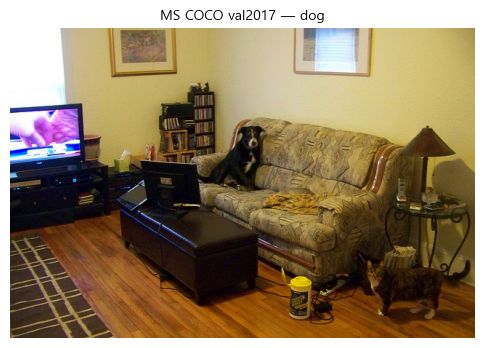

In [3]:
# COCO 공식 CDN — val2017 이미지를 개별 URL로 제공
COCO_IMAGE_BASE = "http://images.cocodataset.org/val2017/"

# MS COCO val2017 — 카테고리별 샘플 URL (카테고리당 5장, 전체 다운로드 불필요)
COCO_IMAGE_CATALOG: dict[str, list[dict]] = {
    "dog": [
        {"file_name": "000000543581.jpg", "image_id": 543581},
        {"file_name": "000000017029.jpg", "image_id": 17029},
        {"file_name": "000000022192.jpg", "image_id": 22192},
        {"file_name": "000000022892.jpg", "image_id": 22892},
        {"file_name": "000000029393.jpg", "image_id": 29393},
    ],
    "cat": [
        {"file_name": "000000039769.jpg", "image_id": 39769},
        {"file_name": "000000001675.jpg", "image_id": 1675},
        {"file_name": "000000004795.jpg", "image_id": 4795},
        {"file_name": "000000010363.jpg", "image_id": 10363},
        {"file_name": "000000014007.jpg", "image_id": 14007},
    ],
    "car": [
        {"file_name": "000000527220.jpg", "image_id": 527220},
        {"file_name": "000000000724.jpg", "image_id": 724},
        {"file_name": "000000001532.jpg", "image_id": 1532},
        {"file_name": "000000005037.jpg", "image_id": 5037},
        {"file_name": "000000006040.jpg", "image_id": 6040},
    ],
    "bird": [
        {"file_name": "000000001268.jpg", "image_id": 1268},
        {"file_name": "000000002923.jpg", "image_id": 2923},
        {"file_name": "000000010092.jpg", "image_id": 10092},
        {"file_name": "000000015751.jpg", "image_id": 15751},
        {"file_name": "000000017899.jpg", "image_id": 17899},
    ],
    "boat": [
        {"file_name": "000000020571.jpg", "image_id": 20571},
        {"file_name": "000000031322.jpg", "image_id": 31322},
        {"file_name": "000000036678.jpg", "image_id": 36678},
        {"file_name": "000000002923.jpg", "image_id": 2923},
        {"file_name": "000000001268.jpg", "image_id": 1268},
    ],
    "airplane": [
        {"file_name": "000000001761.jpg", "image_id": 1761},
        {"file_name": "000000005477.jpg", "image_id": 5477},
        {"file_name": "000000013348.jpg", "image_id": 13348},
        {"file_name": "000000022396.jpg", "image_id": 22396},
        {"file_name": "000000033114.jpg", "image_id": 33114},
    ],
    "horse": [
        {"file_name": "000000007281.jpg", "image_id": 7281},
        {"file_name": "000000012748.jpg", "image_id": 12748},
        {"file_name": "000000015956.jpg", "image_id": 15956},
        {"file_name": "000000016228.jpg", "image_id": 16228},
        {"file_name": "000000017178.jpg", "image_id": 17178},
    ],
    "truck": [
        {"file_name": "000000007088.jpg", "image_id": 7088},
        {"file_name": "000000006723.jpg", "image_id": 6723},
        {"file_name": "000000006040.jpg", "image_id": 6040},
        {"file_name": "000000001532.jpg", "image_id": 1532},
        {"file_name": "000000000724.jpg", "image_id": 724},
    ],
    "bus": [
        {"file_name": "000000001584.jpg", "image_id": 1584},
        {"file_name": "000000002006.jpg", "image_id": 2006},
        {"file_name": "000000005037.jpg", "image_id": 5037},
        {"file_name": "000000006723.jpg", "image_id": 6723},
        {"file_name": "000000015338.jpg", "image_id": 15338},
    ],
    "bicycle": [
        {"file_name": "000000005001.jpg", "image_id": 5001},
        {"file_name": "000000008211.jpg", "image_id": 8211},
        {"file_name": "000000008899.jpg", "image_id": 8899},
        {"file_name": "000000010363.jpg", "image_id": 10363},
        {"file_name": "000000007386.jpg", "image_id": 7386},
    ],
}

COCO_CLASSES = list(COCO_IMAGE_CATALOG.keys())
_url_image_cache: dict[str, Image.Image] = {}


def load_image_from_url(url: str) -> Image.Image:
    """URL에서 이미지 로드 (캐시 + User-Agent)"""
    if url in _url_image_cache:
        return _url_image_cache[url].copy()

    headers = {"User-Agent": "CLIP-Example-Notebook/1.0 (learning example)"}
    response = requests.get(url, timeout=30, headers=headers)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    _url_image_cache[url] = image
    return image.copy()


def _load_coco_entry(entry: dict) -> Image.Image:
    """카탈로그 항목 1건 → PIL Image"""
    url = COCO_IMAGE_BASE + entry["file_name"]
    return load_image_from_url(url)


def load_coco_sample(category: str, index: int = 0) -> Image.Image:
    """지정 COCO 카테고리의 index번째 샘플 이미지 반환"""
    if category not in COCO_IMAGE_CATALOG:
        raise ValueError(
            f"등록되지 않은 카테고리 '{category}'. "
            f"사용 가능: {', '.join(COCO_CLASSES)}"
        )
    entries = COCO_IMAGE_CATALOG[category]
    if index >= len(entries):
        raise IndexError(f"'{category}' index={index} 범위 초과 (총 {len(entries)}장)")
    return _load_coco_entry(entries[index])


def load_coco_samples(category: str, count: int = 1) -> list[Image.Image]:
    """지정 카테고리에서 최대 count개 샘플 수집 (갤러리·평가용)"""
    entries = COCO_IMAGE_CATALOG[category][:count]
    return [_load_coco_entry(e) for e in entries]


def show_image(image: Image.Image, title: str = ""):
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=10)
    plt.show()


# 예제용 강아지 이미지 — 이후 섹션에서 `image` 변수 재사용
image = load_coco_sample("dog")
print(f"URL: {COCO_IMAGE_BASE}{COCO_IMAGE_CATALOG['dog'][0]['file_name']}")
print(f"category=dog, size={image.size}")
show_image(image, "MS COCO val2017 — dog")

## 4. 이미지-텍스트 유사도 계산

CLIP은 이미지와 텍스트를 각각 벡터로 인코딩한 뒤, 코사인 유사도로 얼마나 잘 맞는지 측정합니다.

In [4]:
# 비교할 텍스트 후보 (CLIP은 영어 프롬프트에 최적화)
texts = [
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a car",
    "a photo of a person",
]

# 이미지·텍스트를 모델 입력 형식으로 변환
inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image  # [1, num_texts] 유사도 점수
    probs = logits_per_image.softmax(dim=1).squeeze(0)  # 확률로 변환 (합 = 1)

print("이미지-텍스트 유사도 (확률):")
for text, prob in zip(texts, probs.cpu().tolist()):
    print(f"  {prob:6.2%}  {text}")

이미지-텍스트 유사도 (확률):
  79.48%  a photo of a dog
  11.15%  a photo of a cat
   0.26%  a photo of a car
   9.11%  a photo of a person


## 5. Zero-shot 이미지 분류

학습 데이터 없이, 원하는 클래스 이름만 텍스트로 주면 분류할 수 있습니다.

In [5]:
# 분류 후보 클래스 — 학습 없이 텍스트 프롬프트만으로 zero-shot 분류
labels = ["dog", "cat", "bird", "horse", "car", "airplane"]
prompts = [f"a photo of a {label}" for label in labels]

inputs = processor(text=prompts, images=image, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1).squeeze(0)

best_idx = probs.argmax().item()
print(f"예측 클래스: {labels[best_idx]} ({probs[best_idx]:.2%})")
print("\n전체 점수:")
for label, prob in sorted(zip(labels, probs.cpu().tolist()), key=lambda x: x[1], reverse=True):
    print(f"  {prob:6.2%}  {label}")

예측 클래스: dog (82.31%)

전체 점수:
  82.31%  dog
  11.54%  cat
   5.17%  horse
   0.64%  bird
   0.27%  car
   0.07%  airplane


## 6. 텍스트 쿼리로 가장 잘 맞는 이미지 찾기

여러 이미지 후보 중에서 텍스트 설명과 가장 유사한 이미지를 선택합니다.

쿼리: 'a cute pet animal'
가장 유사한 이미지: cat (score=0.2306)


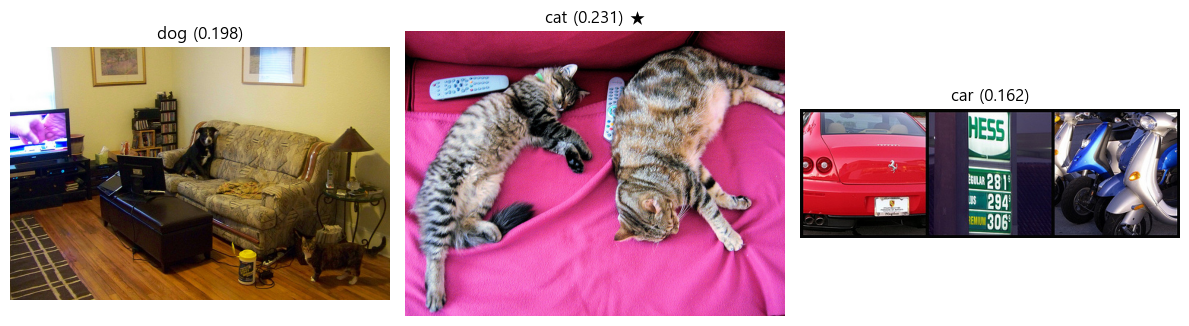

In [6]:
# 텍스트 쿼리와 비교할 이미지 후보 (COCO URL)
candidate_images = [
    load_coco_sample("dog"),
    load_coco_sample("cat"),
    load_coco_sample("car"),
]
candidate_labels = ["dog", "cat", "car"]

query = "a cute pet animal"

# 텍스트 임베딩 추출 및 L2 정규화 (코사인 유사도 계산용)
text_inputs = processor(text=[query], return_tensors="pt", padding=True)
text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

with torch.no_grad():
    text_features = to_feature_tensor(model.get_text_features(**text_inputs))
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# 각 후보 이미지와 텍스트 쿼리의 코사인 유사도 계산
scores = []
for img in candidate_images:
    image_inputs = processor(images=img, return_tensors="pt")
    image_inputs = {k: v.to(device) for k, v in image_inputs.items()}
    with torch.no_grad():
        image_features = to_feature_tensor(model.get_image_features(**image_inputs))
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        score = (image_features @ text_features.T).item()  # 내적 = 코사인 유사도
    scores.append(score)

best_image_idx = max(range(len(scores)), key=lambda i: scores[i])
print(f"쿼리: '{query}'")
print(f"가장 유사한 이미지: {candidate_labels[best_image_idx]} (score={scores[best_image_idx]:.4f})")

# 후보별 유사도 시각화 (★ = 최고 점수)
fig, axes = plt.subplots(1, len(candidate_images), figsize=(12, 4))
for ax, img, score, idx, label in zip(
    axes, candidate_images, scores, range(len(candidate_images)), candidate_labels
):
    ax.imshow(img)
    ax.axis("off")
    marker = " ★" if idx == best_image_idx else ""
    ax.set_title(f"{label} ({score:.3f}){marker}")
plt.tight_layout()
plt.show()

## 7. 직접 임베딩 추출하기

이미지/텍스트 임베딩을 따로 뽑아 검색, 클러스터링, 유사 이미지 찾기 등에 활용할 수 있습니다.

In [7]:
def get_image_embedding(img: Image.Image) -> torch.Tensor:
    """이미지 → 512차원 L2 정규화 임베딩"""
    inputs = processor(images=img, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        features = to_feature_tensor(model.get_image_features(**inputs))
    return features / features.norm(dim=-1, keepdim=True)


def get_text_embedding(text: str) -> torch.Tensor:
    """텍스트 → 512차원 L2 정규화 임베딩"""
    inputs = processor(text=[text], return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        features = to_feature_tensor(model.get_text_features(**inputs))
    return features / features.norm(dim=-1, keepdim=True)


# 이미지·텍스트 임베딩 추출 후 코사인 유사도 계산
image_emb = get_image_embedding(image)
text_emb = get_text_embedding("a photo of a dog")

similarity = (image_emb @ text_emb.T).item()
print(f"임베딩 차원: {image_emb.shape[-1]}")
print(f"이미지-텍스트 코사인 유사도: {similarity:.4f}")

임베딩 차원: 512
이미지-텍스트 코사인 유사도: 0.2394


## 8. 배치 임베딩 인덱스 — 이미지 검색 엔진

여러 이미지를 한꺼번에 임베딩하고, 텍스트·이미지 쿼리로 Top-K 검색하는 인덱스 클래스입니다.
실제 이미지 검색 서비스의 핵심 구조와 동일합니다.

In [8]:
import numpy as np
from dataclasses import dataclass


@dataclass
class SearchResult:
    index: int
    score: float
    label: str | None
    image: Image.Image


class CLIPEmbeddingIndex:
    """CLIP 임베딩 기반 이미지 검색 인덱스"""

    def __init__(self, model, processor, device):
        self.model = model
        self.processor = processor
        self.device = device
        self.images: list[Image.Image] = []
        self.labels: list[str | None] = []
        self._embeddings: torch.Tensor | None = None  # [N, dim] L2 정규화됨

    @torch.no_grad()
    def _encode_images_batch(self, images: list[Image.Image], batch_size: int = 32) -> torch.Tensor:
        """이미지 리스트 → 정규화 임베딩 행렬 [N, dim]"""
        all_features = []
        for start in range(0, len(images), batch_size):
            batch = images[start : start + batch_size]
            inputs = self.processor(images=batch, return_tensors="pt", padding=True)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            features = to_feature_tensor(self.model.get_image_features(**inputs))
            features = features / features.norm(dim=-1, keepdim=True)
            all_features.append(features.cpu())
        return torch.cat(all_features, dim=0)

    @torch.no_grad()
    def encode_texts(self, texts: list[str]) -> torch.Tensor:
        """텍스트 리스트 → 정규화 임베딩 행렬 [M, dim]"""
        inputs = self.processor(text=texts, return_tensors="pt", padding=True)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        features = to_feature_tensor(self.model.get_text_features(**inputs))
        return features / features.norm(dim=-1, keepdim=True)

    def add_images(self, images: list[Image.Image], labels: list[str] | None = None):
        """갤러리에 이미지 추가 (기존 인덱스에 append)"""
        if labels is None:
            labels = [None] * len(images)
        new_emb = self._encode_images_batch(images)
        self.images.extend(images)
        self.labels.extend(labels)
        self._embeddings = (
            new_emb if self._embeddings is None else torch.cat([self._embeddings, new_emb], dim=0)
        )

    def _search(self, query_emb: torch.Tensor, top_k: int = 5) -> list[SearchResult]:
        """쿼리 임베딩 1개로 Top-K 검색"""
        query_emb = query_emb.cpu()
        scores = (self._embeddings @ query_emb.T).squeeze(1)  # [N]
        top_k = min(top_k, len(self.images))
        top_scores, top_indices = scores.topk(top_k)
        return [
            SearchResult(
                index=idx.item(),
                score=score.item(),
                label=self.labels[idx.item()],
                image=self.images[idx.item()],
            )
            for score, idx in zip(top_scores, top_indices)
        ]

    def search_by_text(self, query: str, top_k: int = 5) -> list[SearchResult]:
        with torch.no_grad():
            query_emb = self.encode_texts([query])
        return self._search(query_emb[0:1], top_k)

    def search_by_image(self, query_image: Image.Image, top_k: int = 5) -> list[SearchResult]:
        query_emb = self._encode_images_batch([query_image])
        return self._search(query_emb, top_k)

    def __len__(self):
        return len(self.images)


def show_search_results(query_desc: str, results: list[SearchResult]):
    """검색 결과를 그리드로 시각화"""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        ax.imshow(r.image)
        ax.axis("off")
        label = r.label or f"#{r.index}"
        ax.set_title(f"{label}\nscore={r.score:.3f}", fontsize=9)
    fig.suptitle(query_desc, fontsize=11)
    plt.tight_layout()
    plt.show()


print("CLIPEmbeddingIndex 준비 완료")

CLIPEmbeddingIndex 준비 완료


## 9. Prompt Ensemble — 다중 프롬프트 앙상블

단일 프롬프트(`a photo of a dog`) 대신 여러 템플릿의 임베딩을 평균하면 zero-shot 정확도가 향상됩니다.
CLIP 논문에서도 사용하는 기법입니다.

In [9]:
# CLIP 논문 스타일 프롬프트 템플릿 (클래스명 {}에 삽입)
PROMPT_TEMPLATES = [
    "a photo of a {}.",
    "a blurry photo of a {}.",
    "a black and white photo of a {}.",
    "a low resolution photo of a {}.",
    "a cropped photo of a {}.",
    "a bright photo of a {}.",
    "a dark photo of a {}.",
    "a drawing of a {}.",
    "a painting of a {}.",
    "a sketch of a {}.",
]


@torch.no_grad()
def build_class_embeddings(labels: list[str], templates: list[str]) -> torch.Tensor:
    """클래스별 다중 프롬프트 임베딩 평균 → [num_classes, dim]"""
    class_embeddings = []
    for label in labels:
        prompts = [t.format(label) for t in templates]
        inputs = processor(text=prompts, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        features = to_feature_tensor(model.get_text_features(**inputs))
        features = features / features.norm(dim=-1, keepdim=True)
        class_embeddings.append(features.mean(dim=0))  # 템플릿 평균
    class_embeddings = torch.stack(class_embeddings)
    return class_embeddings / class_embeddings.norm(dim=-1, keepdim=True)


@torch.no_grad()
def classify_with_class_embeddings(img: Image.Image, labels: list[str], class_emb: torch.Tensor) -> tuple[str, torch.Tensor]:
    """이미지 1장을 클래스 임베딩 행렬과 비교해 분류"""
    inputs = processor(images=img, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    img_emb = to_feature_tensor(model.get_image_features(**inputs))
    img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
    logits = (100.0 * img_emb @ class_emb.T).squeeze(0)  # CLIP temperature scale
    probs = logits.softmax(dim=0)
    return labels[probs.argmax().item()], probs


eval_labels = ["dog", "cat", "bird", "horse", "car", "airplane"]

# 단일 프롬프트 vs 앙상블 비교
single_prompts = [f"a photo of a {l}" for l in eval_labels]
single_inputs = processor(text=single_prompts, images=image, return_tensors="pt", padding=True)
single_inputs = {k: v.to(device) for k, v in single_inputs.items()}
with torch.no_grad():
    single_probs = model(**single_inputs).logits_per_image.softmax(dim=1).squeeze(0)

ensemble_emb = build_class_embeddings(eval_labels, PROMPT_TEMPLATES)
_, ensemble_probs = classify_with_class_embeddings(image, eval_labels, ensemble_emb)

print(f"테스트 이미지: dog\n")
print(f"{'클래스':<12} {'단일 프롬프트':>14} {'앙상블':>14}")
print("-" * 42)
for label, s, e in zip(eval_labels, single_probs.cpu().tolist(), ensemble_probs.cpu().tolist()):
    print(f"{label:<12} {s:>13.2%} {e:>13.2%}")

테스트 이미지: dog

클래스                 단일 프롬프트            앙상블
------------------------------------------
dog                 82.31%        87.89%
cat                 11.54%         9.52%
bird                 0.64%         0.46%
horse                5.17%         1.94%
car                  0.27%         0.15%
airplane             0.07%         0.03%


## 10. 멀티 쿼리 이미지 검색

MS COCO URL 샘플로 갤러리를 구축하고, 여러 텍스트 쿼리로 Top-3 이미지를 검색합니다.

갤러리 구축 완료: 25장 (5 클래스 × 5장)


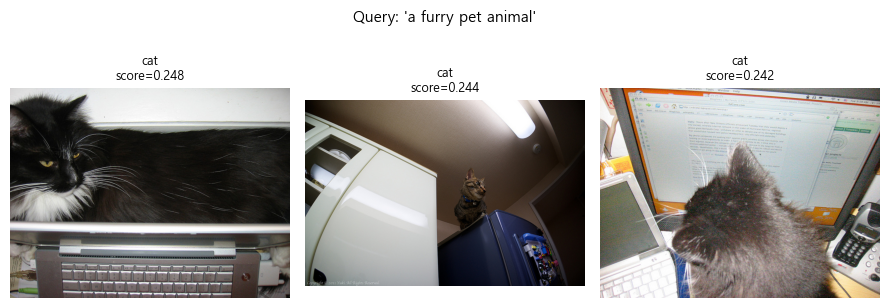

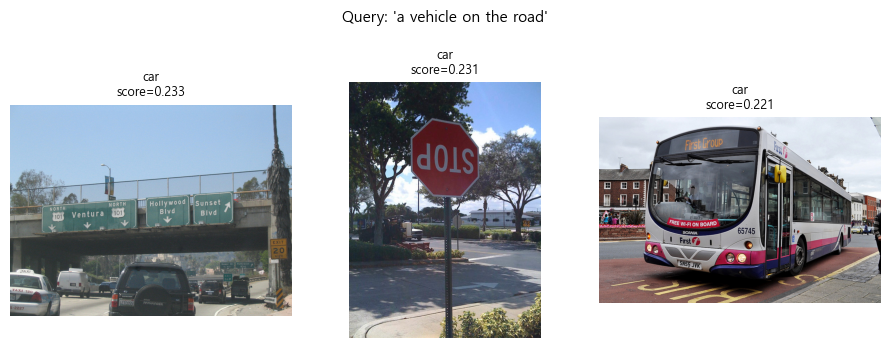

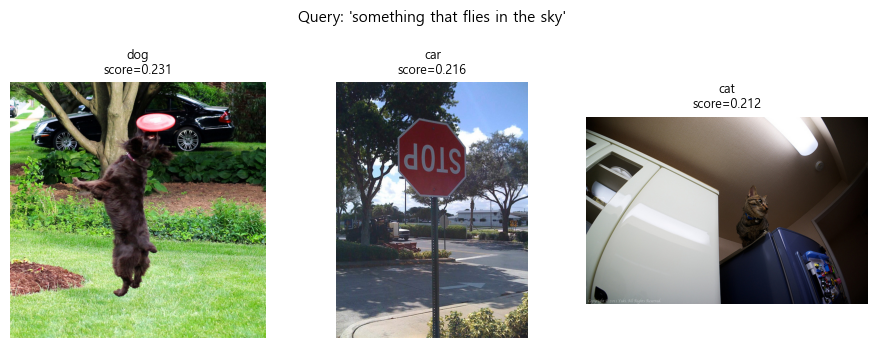

In [10]:
# 클래스당 5장씩 갤러리 구축 (총 25장) — COCO URL 카탈로그 사용
GALLERY_CLASSES = ["dog", "cat", "car", "bird", "boat"]
SAMPLES_PER_CLASS = 5

index = CLIPEmbeddingIndex(model, processor, device)
for cls in GALLERY_CLASSES:
    imgs = load_coco_samples(cls, count=SAMPLES_PER_CLASS)
    index.add_images(imgs, labels=[cls] * len(imgs))

print(f"갤러리 구축 완료: {len(index)}장 ({len(GALLERY_CLASSES)} 클래스 × {SAMPLES_PER_CLASS}장)")

# 여러 텍스트 쿼리로 검색
queries = [
    "a furry pet animal",
    "a vehicle on the road",
    "something that flies in the sky",
]

for query in queries:
    results = index.search_by_text(query, top_k=3)
    show_search_results(f"Query: '{query}'", results)

## 11. MS COCO Zero-shot 정확도 평가

MS COCO URL 샘플 10클래스 × 5장(총 50장)으로 zero-shot 정확도를 측정하고 혼동 행렬(confusion matrix)을 그립니다.
단일 프롬프트와 Prompt Ensemble 성능을 비교합니다.

평가 데이터: 50장 (10 클래스 × 5장)

[단일 프롬프트] 정확도: 64.00% (32/50)

[Prompt Ensemble] 정확도: 62.00% (31/50)


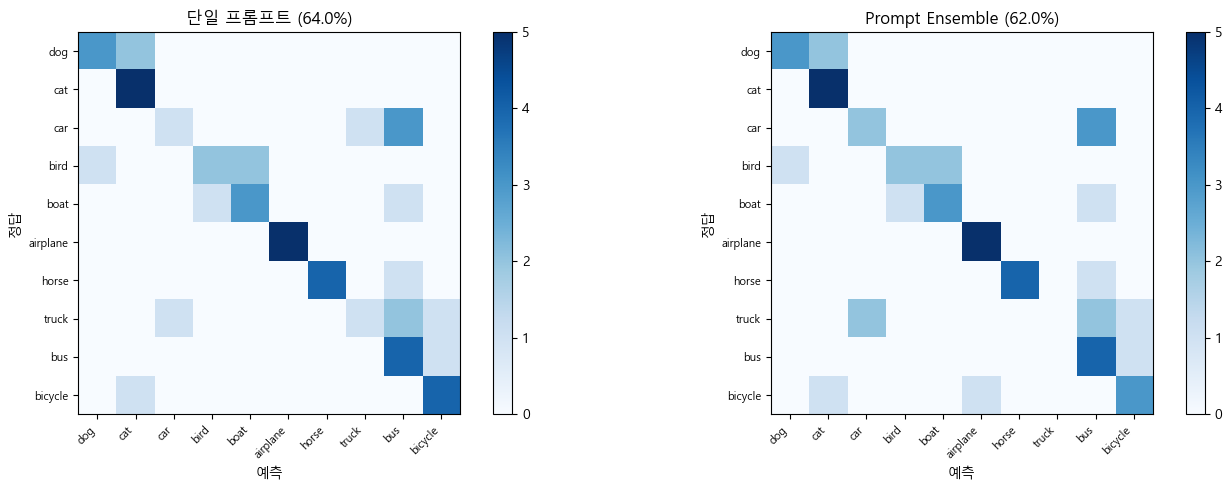

In [11]:
ALL_CLASSES = COCO_CLASSES  # dog, cat, car, bird, boat, airplane, horse, truck, bus, bicycle
EVAL_SAMPLES = 5  # 카탈로그에 등록된 URL 수와 동일

# 평가용 이미지·정답 라벨 수집
eval_images, eval_true_labels = [], []
for cls in ALL_CLASSES:
    imgs = load_coco_samples(cls, count=EVAL_SAMPLES)
    eval_images.extend(imgs)
    eval_true_labels.extend([cls] * len(imgs))

print(f"평가 데이터: {len(eval_images)}장 ({len(ALL_CLASSES)} 클래스 × {EVAL_SAMPLES}장)")

# 클래스 임베딩 사전 계산 (앙상블)
ensemble_class_emb = build_class_embeddings(ALL_CLASSES, PROMPT_TEMPLATES)


def evaluate_zero_shot(images, true_labels, class_labels, class_emb, desc: str):
    """zero-shot 분류 정확도 + 혼동 행렬 반환"""
    n = len(class_labels)
    confusion = np.zeros((n, n), dtype=int)
    correct = 0

    for img, true in zip(images, true_labels):
        pred, _ = classify_with_class_embeddings(img, class_labels, class_emb)
        true_idx = class_labels.index(true)
        pred_idx = class_labels.index(pred)
        confusion[true_idx, pred_idx] += 1
        if pred == true:
            correct += 1

    accuracy = correct / len(images)
    print(f"\n[{desc}] 정확도: {accuracy:.2%} ({correct}/{len(images)})")
    return accuracy, confusion


# 단일 프롬프트용 클래스 임베딩
single_class_emb = build_class_embeddings(ALL_CLASSES, ["a photo of a {}."])

acc_single, cm_single = evaluate_zero_shot(
    eval_images, eval_true_labels, ALL_CLASSES, single_class_emb, "단일 프롬프트"
)
acc_ensemble, cm_ensemble = evaluate_zero_shot(
    eval_images, eval_true_labels, ALL_CLASSES, ensemble_class_emb, "Prompt Ensemble"
)

# 혼동 행렬 시각화 (앙상블 결과)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title in zip(
    axes,
    [cm_single, cm_ensemble],
    [f"단일 프롬프트 ({acc_single:.1%})", f"Prompt Ensemble ({acc_ensemble:.1%})"],
):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(ALL_CLASSES)))
    ax.set_yticks(range(len(ALL_CLASSES)))
    ax.set_xticklabels(ALL_CLASSES, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ALL_CLASSES, fontsize=8)
    ax.set_xlabel("예측")
    ax.set_ylabel("정답")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 12. 이미지-이미지 유사도 검색

텍스트 없이, 쿼리 이미지와 시각적으로 가장 유사한 이미지를 갤러리에서 찾습니다.
(같은 클래스 내 유사 이미지 탐색, 중복 탐지 등에 활용)

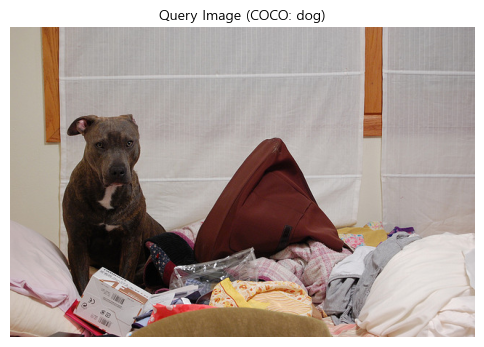

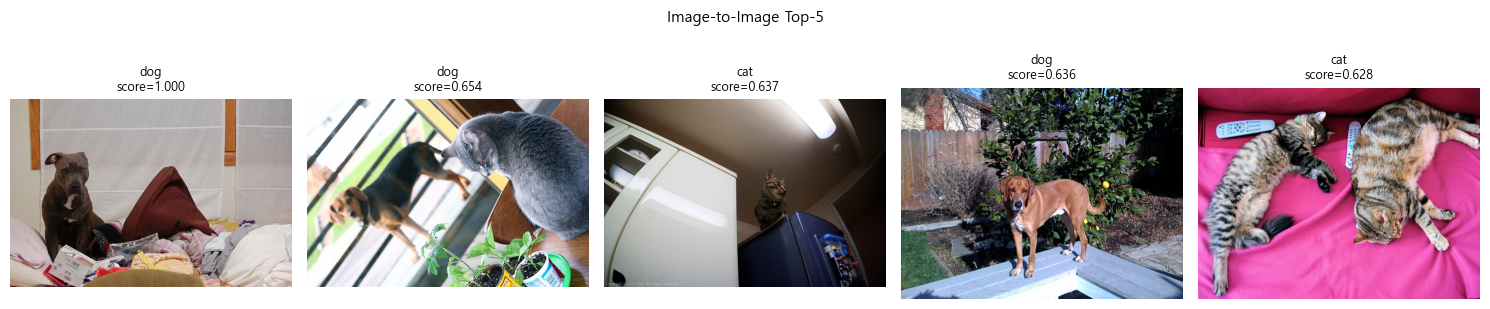

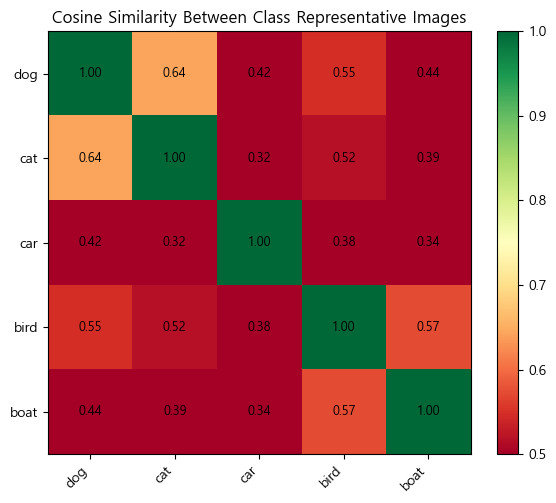

In [12]:
# 쿼리: 강아지 이미지 → 갤러리(섹션 10)에서 유사 이미지 Top-5 검색
query_img = load_coco_sample("dog", index=2)  # 첫 샘플과 다른 COCO URL 사용

show_image(query_img, "Query Image (COCO: dog)")

results = index.search_by_image(query_img, top_k=5)
show_search_results("Image-to-Image Top-5", results)

# 유사도 행렬 히트맵 — 갤러리 5클래스 × 클래스당 1장 대표 이미지
representatives = [load_coco_sample(cls) for cls in GALLERY_CLASSES]
rep_emb = index._encode_images_batch(representatives)
sim_matrix = (rep_emb @ rep_emb.T).numpy()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(GALLERY_CLASSES)))
ax.set_yticks(range(len(GALLERY_CLASSES)))
ax.set_xticklabels(GALLERY_CLASSES, rotation=45, ha="right")
ax.set_yticklabels(GALLERY_CLASSES)
ax.set_title("Cosine Similarity Between Class Representative Images") # 클래스 대표 이미지 간 코사인 유사도
for i in range(len(GALLERY_CLASSES)):
    for j in range(len(GALLERY_CLASSES)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 다음 단계

- **로컬 이미지**: `Image.open("your_image.jpg")`로 바꿔 실험해 보세요.
- **더 큰 모델**: `openai/clip-vit-large-patch14`로 정확도를 높일 수 있습니다.
- **한국어**: CLIP은 영어에 최적화되어 있습니다. 한국어는 `a photo of 강아지`보다 영어 프롬프트가 보통 더 잘 동작합니다.
- **대규모 검색**: `CLIPEmbeddingIndex`를 FAISS/Milvus 등 벡터 DB와 연동하면 수백만 장 규모 검색이 가능합니다.
- **응용**: 이미지 검색, 콘텐츠 필터링, 라벨 없는 데이터 분류, 중복 이미지 탐지 등에 활용할 수 있습니다.